# Training ORIGAMI with Continuous Numeric Values

This notebook demonstrates how to train an ORIGAMI model using continuous numeric values with the `OrigamiPipeline` API.

The continuous head uses a Mixture of Gaussians (MoG) output to model numeric values, allowing the model to learn rich distributions over continuous fields rather than discretizing them into bins.

**Key features demonstrated:**
- Using `OrigamiPipeline` for end-to-end training and inference
- `numeric_mode="scale"` for automatic preprocessing of high-cardinality numerics
- Automatic inverse transformation of predictions back to original scale

## 1. Create 2D Gaussian Dataset

We create a synthetic dataset with two correlated numeric fields `a` and `b` following a 2D Gaussian distribution.

In [1]:
import random

import numpy as np
import torch

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_DOCS = 10000

# Create 2D Gaussian data with correlation
mean = [4, -2]
cov = [[1.0, 0.7], [0.7, 0.5]]  # Correlated covariance matrix

samples = np.random.multivariate_normal(mean, cov, NUM_DOCS)
docs = [{"a": float(x), "b": float(y)} for x, y in samples]

print(f"Created {len(docs)} documents")
print(f"Sample docs: {docs[:3]}")

Created 10000 documents
Sample docs: [{'a': 3.5103557462352297, 'b': -2.3589035228017097}, {'a': 3.281236621343086, 'b': -2.3540538636051225}, {'a': 4.244930169168411, 'b': -1.8508327613463913}]


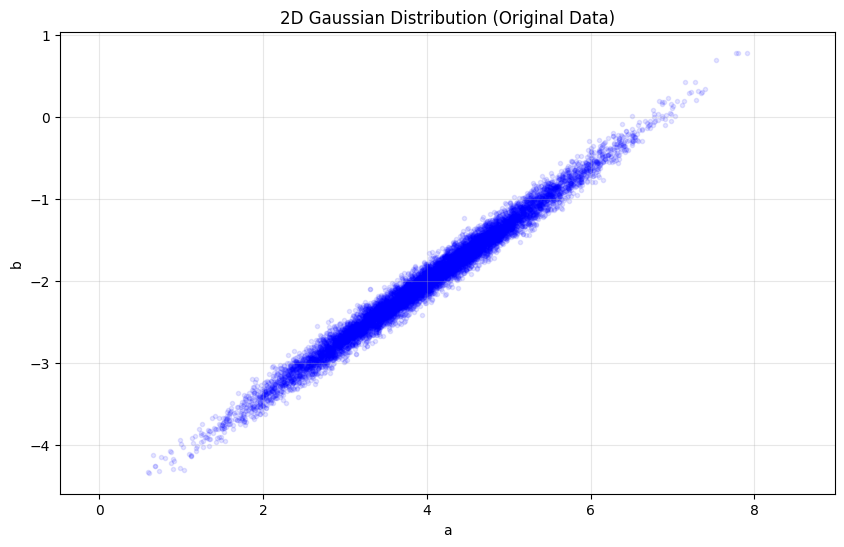

In [2]:
# Plot the data in a 2D scatter plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter([d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.1, color="blue")
plt.title("2D Gaussian Distribution (Original Data)")
plt.xlabel("a")
plt.ylabel("b")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Configure and Train with OrigamiPipeline

The `OrigamiPipeline` handles all the complexity:
- **Preprocessing**: Automatically identifies high-cardinality numeric fields and applies NumericScaler
- **Tokenization**: Fits the tokenizer on the preprocessed data
- **Model creation**: Creates the model with continuous head enabled
- **Training**: Trains with the specified configuration

With `numeric_mode="scale"`, fields with more than `cat_threshold` unique values are normalized using StandardScaler and the model uses a Mixture of Gaussians output head for predictions.

In [3]:
from origami import OrigamiPipeline, PipelineConfig

# Configure pipeline with continuous numeric handling
config = PipelineConfig(
    # Model architecture
    d_model=64,
    n_heads=4,
    n_layers=4,
    d_ff=256,
    dropout=0.0,
    # Numeric handling - "scale" enables continuous head with MoG
    numeric_mode="scale",
    cat_threshold=20,  # Fields with >20 unique values get scaled
    num_mixture_components=5,
    # Training
    batch_size=64,
    learning_rate=1e-3,
    warmup_steps=100,
    num_epochs=20,
    shuffle_keys=False,  # Key order doesn't matter for this simple dataset
)

# Create pipeline
pipeline = OrigamiPipeline(config)
print(f"Pipeline config: d_model={config.d_model}, numeric_mode={config.numeric_mode}")

Pipeline config: d_model=64, numeric_mode=scale


## 3. Train the Pipeline

A single `fit()` call handles everything: preprocessing, tokenization, model creation, and training.

In [ ]:
# Split data
train_size = int(0.9 * len(docs))
train_docs = docs[:train_size]
eval_docs = docs[train_size:]

print(f"Train size: {len(train_docs)}")
print(f"Eval size: {len(eval_docs)}")

# Fit the pipeline (handles preprocessing, tokenization, model creation, training)
pipeline.fit(train_docs, eval_data=eval_docs)

print(f"\nModel parameters: {pipeline._model.get_num_parameters():,}")
print(f"Continuous head enabled: {pipeline._model.continuous_head is not None}")

In [4]:
# save pipeline
# pipeline.save("origami_2d_gaussian_pipeline.pt")

# optionally load pipeline
pipeline = OrigamiPipeline.load("origami_2d_gaussian_pipeline.pt")

## 4. Inspect the Preprocessor

The pipeline automatically created a NumericScaler and fitted it on the training data. We can inspect what fields were scaled.

In [5]:
# The pipeline's preprocessor is a NumericScaler
print("Preprocessor summary:")
print(pipeline._preprocessor.summary())

pipeline.config.max_depth

Preprocessor summary:
NumericScaler (cat_threshold=20)
  Scaled fields (2):
    a: mean=3.998, std=1.01
    b: mean=-2.001, std=0.7141
  Pass-through fields (0):


8

## 5. Generate Samples from the Model

The `generate()` method samples complete JSON objects from the model. When the model generates a `NUM` token, it samples from the learned Mixture of Gaussians distribution.

**Important:** The pipeline automatically inverse-transforms generated values back to the original scale.

In [6]:
# Generate samples - values are automatically inverse-transformed to original scale
n_samples = 1000
generated_samples = pipeline.generate(num_samples=n_samples, temperature=0.8, top_p=0.95)

print(f"Generated {len(generated_samples)} samples")
print(f"Sample generated docs: {generated_samples[:3]}")

# Extract values for plotting - only keep samples where both a and b are numeric
generated_a = []
generated_b = []
for s in generated_samples:
    if isinstance(s, dict) and "a" in s and "b" in s:
        a_val, b_val = s["a"], s["b"]
        if isinstance(a_val, (int, float)) and isinstance(b_val, (int, float)):
            generated_a.append(float(a_val))
            generated_b.append(float(b_val))

print(f"\nSuccessfully extracted {len(generated_a)} / {n_samples} valid samples")
if len(generated_a) < n_samples:
    print(f"({n_samples - len(generated_a)} samples had non-numeric or missing values)")


Generated 1000 samples
Sample generated docs: [{'a': 5.57495299902308, 'b': -0.884889717811453}, {'a': 2.104896516776691, 'b': -3.3587767267051145}, {'a': 4.120416843013373, 'b': -1.9405857547293726}]

Successfully extracted 1000 / 1000 valid samples


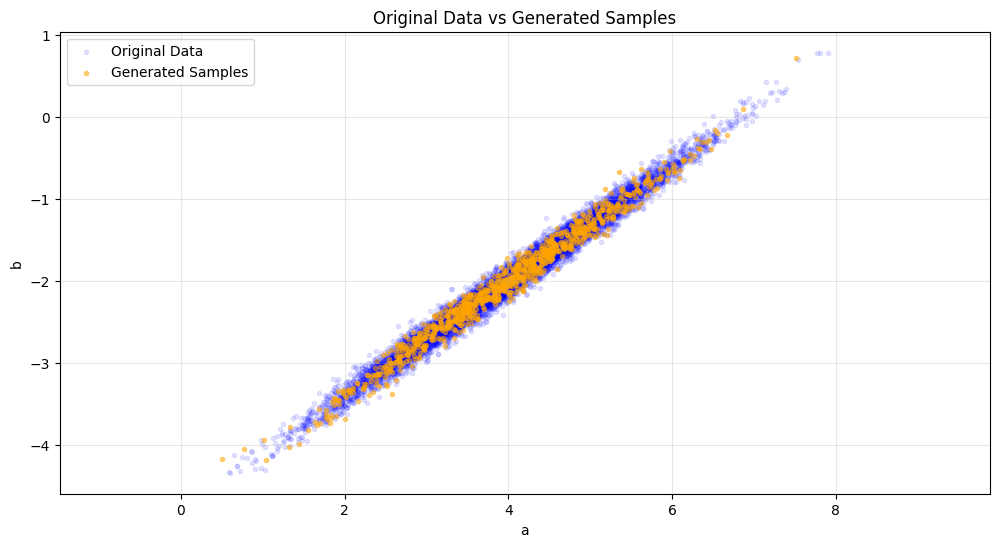

In [7]:
# Plot original data vs generated samples
fig, ax = plt.subplots(figsize=(12, 6))

# Original data
plt.scatter([d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.1, color="blue", label="Original Data")

# Generated samples
plt.scatter(generated_a, generated_b, marker=".", alpha=0.5, color="orange", label="Generated Samples")

plt.title("Original Data vs Generated Samples")
plt.xlabel("a")
plt.ylabel("b")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Visualize Marginal Distributions

Let's compare the marginal distributions of the original data vs generated samples.

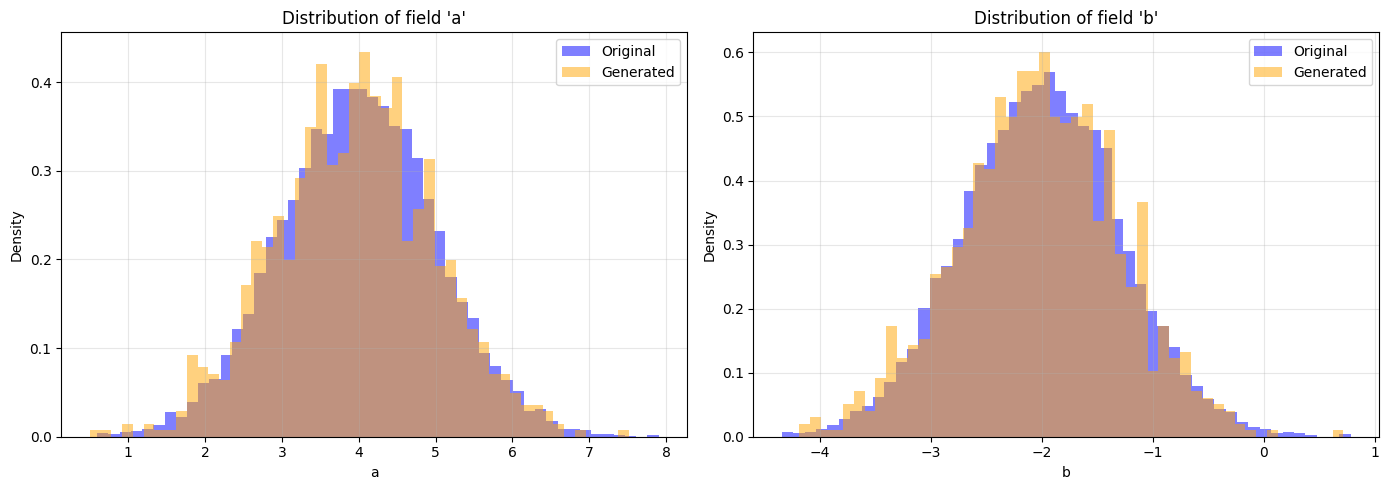

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Field 'a' distribution
axes[0].hist([d["a"] for d in docs], bins=50, alpha=0.5, density=True, label="Original", color="blue")
axes[0].hist(generated_a, bins=50, alpha=0.5, density=True, label="Generated", color="orange")
axes[0].set_title("Distribution of field 'a'")
axes[0].set_xlabel("a")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Field 'b' distribution
axes[1].hist([d["b"] for d in docs], bins=50, alpha=0.5, density=True, label="Original", color="blue")
axes[1].hist(generated_b, bins=50, alpha=0.5, density=True, label="Generated", color="orange")
axes[1].set_title("Distribution of field 'b'")
axes[1].set_xlabel("b")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Predict 'b' from 'a' using Pipeline

We can use `pipeline.predict()` to predict the value of `b` given `a`. This tests whether the model has learned the correlation between the two fields.

**Note:** The prediction is automatically inverse-transformed to the original scale.

In [9]:
# Create test data: sample every 100th point for visualization
test_indices = list(range(0, len(docs), 100))
test_docs = [docs[i] for i in test_indices]

print(f"Test set size: {len(test_docs)}")

# Store ground truth values
true_a = [d["a"] for d in test_docs]
true_b = [d["b"] for d in test_docs]

# Create prediction inputs (with target field set to None)
pred_inputs = [{"a": d["a"], "b": None} for d in test_docs]

# Predict using pipeline - values are automatically inverse-transformed!
# predict_batch now returns list[Any] directly
predictions = pipeline.predict_batch(pred_inputs, target_key="b")
predicted_b = predictions  # Values are returned directly

print(f"Predicted {len(predicted_b)} values")
print("\nSample predictions (already in original scale):")
for i in range(3):
    print(f"  a={true_a[i]:.3f} -> predicted b={predicted_b[i]:.3f} (true: {true_b[i]:.3f})")

Test set size: 100
Predicted 100 values

Sample predictions (already in original scale):
  a=3.510 -> predicted b=-2.441 (true: -2.359)
  a=3.616 -> predicted b=-2.269 (true: -2.214)
  a=5.621 -> predicted b=-0.708 (true: -0.918)


In [10]:
# Calculate metrics
mse = np.mean([(pred - true) ** 2 for pred, true in zip(predicted_b, true_b, strict=True)])
mae = np.mean([abs(pred - true) for pred, true in zip(predicted_b, true_b, strict=True)])
rmse = np.sqrt(mse)

# Baseline: predict mean
baseline_mse = np.mean([(mean[1] - true) ** 2 for true in true_b])
baseline_rmse = np.sqrt(baseline_mse)

print("Prediction Metrics:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print("\nBaseline (predict mean):")
print(f"  MSE:  {baseline_mse:.4f}")
print(f"  RMSE: {baseline_rmse:.4f}")

Prediction Metrics:
  MSE:  0.0147
  RMSE: 0.1213
  MAE:  0.0963

Baseline (predict mean):
  MSE:  0.5002
  RMSE: 0.7073


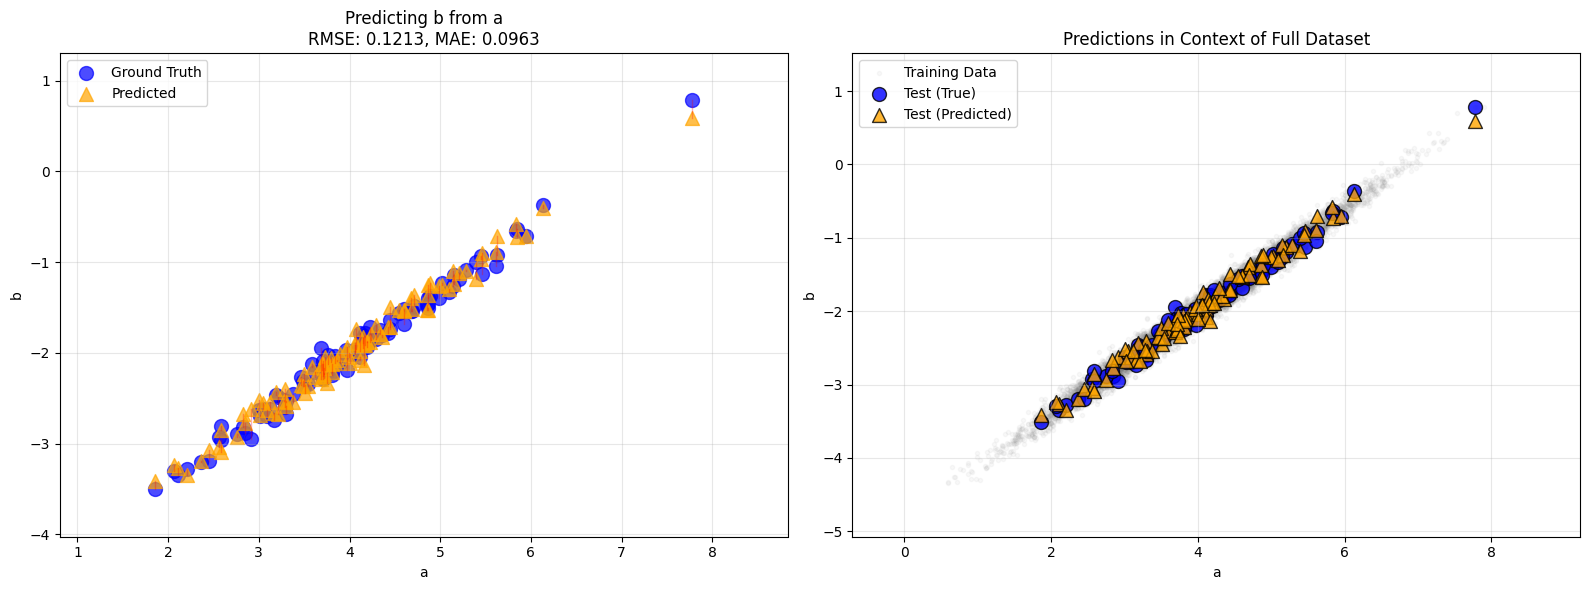

In [11]:
# Visualize predictions vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Predictions vs Ground Truth scatter
axes[0].scatter(true_a, true_b, alpha=0.7, s=100, label="Ground Truth", color="blue")
axes[0].scatter(true_a, predicted_b, alpha=0.7, s=100, label="Predicted", color="orange", marker="^")

# Draw lines connecting true to predicted for each point
for ta, tb, pb in zip(true_a, true_b, predicted_b, strict=True):
    axes[0].plot([ta, ta], [tb, pb], "r-", alpha=0.3, linewidth=1)

axes[0].set_xlabel("a")
axes[0].set_ylabel("b")
axes[0].set_title(f"Predicting b from a\nRMSE: {rmse:.4f}, MAE: {mae:.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axis("equal")

# Right plot: Show predictions overlaid on training data
axes[1].scatter(
    [d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.05, color="gray", label="Training Data"
)
axes[1].scatter(true_a, true_b, alpha=0.8, s=100, label="Test (True)", color="blue", edgecolors="black", linewidths=1)
axes[1].scatter(
    true_a,
    predicted_b,
    alpha=0.8,
    s=100,
    label="Test (Predicted)",
    color="orange",
    marker="^",
    edgecolors="black",
    linewidths=1,
)

axes[1].set_xlabel("a")
axes[1].set_ylabel("b")
axes[1].set_title("Predictions in Context of Full Dataset")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axis("equal")

plt.tight_layout()
plt.show()

## 8. Example Predictions Table

In [12]:
# Show example predictions
print("Example Predictions:")
print("=" * 60)
print(f"{'a value':<12} {'True b':<12} {'Predicted b':<12} {'Error':<12}")
print("=" * 60)
for i in range(min(15, len(test_docs))):
    error = predicted_b[i] - true_b[i]
    print(f"{true_a[i]:<12.3f} {true_b[i]:<12.3f} {predicted_b[i]:<12.3f} {error:<+12.3f}")

Example Predictions:
a value      True b       Predicted b  Error       
3.510        -2.359       -2.441       -0.082      
3.616        -2.214       -2.269       -0.054      
5.621        -0.918       -0.708       +0.210      
3.287        -2.595       -2.400       +0.195      
3.087        -2.695       -2.630       +0.065      
2.559        -2.923       -3.042       -0.119      
3.895        -2.117       -2.013       +0.104      
5.020        -1.227       -1.254       -0.026      
4.118        -1.779       -1.974       -0.195      
2.104        -3.342       -3.269       +0.073      
4.681        -1.534       -1.398       +0.136      
2.207        -3.283       -3.345       -0.062      
4.713        -1.480       -1.358       +0.122      
5.845        -0.638       -0.723       -0.086      
3.689        -1.949       -2.290       -0.341      


## 9. Save and Load Pipeline

The pipeline saves all state (model, tokenizer, preprocessor) in a single checkpoint file.

In [ ]:
import tempfile
from pathlib import Path

# Save pipeline to a temporary file
with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as f:
    save_path = Path(f.name)

pipeline.save(save_path)
print(f"Saved pipeline to {save_path}")
print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")

# Load pipeline
loaded_pipeline = OrigamiPipeline.load(save_path)
print("\nLoaded pipeline:")
print(f"  Fitted: {loaded_pipeline._fitted}")
print(f"  Preprocessor: {type(loaded_pipeline._preprocessor).__name__}")
print(f"  Numeric mode: {loaded_pipeline.config.numeric_mode}")

# Verify predictions match
test_pred = loaded_pipeline.predict({"a": 3.5, "b": None}, target_key="b")
print(f"\nTest prediction from loaded model: {test_pred:.3f}")

# Clean up
save_path.unlink()

## 10. (Advanced) Inspect Learned Mixture Components

For educational purposes, let's look at the internal Mixture of Gaussians parameters that the model learns. This requires accessing the model internals directly.

In [13]:
from origami.preprocessing import move_target_last
from origami.tokenizer.vocabulary import KeyToken
from origami.training import OrigamiDataCollator

# Access internal components
model = pipeline._model
tokenizer = pipeline._tokenizer
scaler = pipeline._preprocessor
collator = OrigamiDataCollator(tokenizer)

# Scale a test document
test_doc = test_docs[0]
scaled_doc = scaler.transform([test_doc])[0]

# Reorder so 'b' is last (target position)
reordered = move_target_last(scaled_doc, "b")

# Tokenize and prepare batch
instance = tokenizer.tokenize(reordered)
batch = collator([instance])

# Forward pass with numeric values for conditioning
model.eval()
with torch.no_grad():
    output = model(
        batch["input_ids"],
        batch["path_types"],
        batch["path_ids"],
        batch["path_lengths"],
        batch["attention_mask"],
        numeric_values=batch["numeric_values"],
    )

# Get continuous params at the position where we predict 'b'
weights, means, log_vars = output.continuous_params
b_key_id = tokenizer.vocab.encode(KeyToken("b"))
b_pos = (batch["input_ids"][0] == b_key_id).nonzero(as_tuple=True)[0][-1].item()

print(f"Input: a = {test_doc['a']:.3f}")
print(f"True b: {test_doc['b']:.3f}")
print("\nMixture parameters at position predicting 'b' value:")
print(f"  Weights: {weights[0, b_pos].numpy()}")
print(f"  Means (scaled): {means[0, b_pos].numpy()}")
print(f"  Stds (scaled): {torch.exp(0.5 * log_vars[0, b_pos]).numpy()}")

Input: a = 3.510
True b: -2.359

Mixture parameters at position predicting 'b' value:
  Weights: [4.46375042e-01 5.03359020e-01 4.99483868e-02 2.12742743e-04
 1.04823004e-04]
  Means (scaled): [-0.4728378  -0.46861792 -0.52698463  0.19612338 -0.16434722]
  Stds (scaled): [0.14354856 0.13188992 0.14801244 1.0357538  0.97830284]


### Visualize the Mixture Distribution

Plot the learned Mixture of Gaussians probability density function.

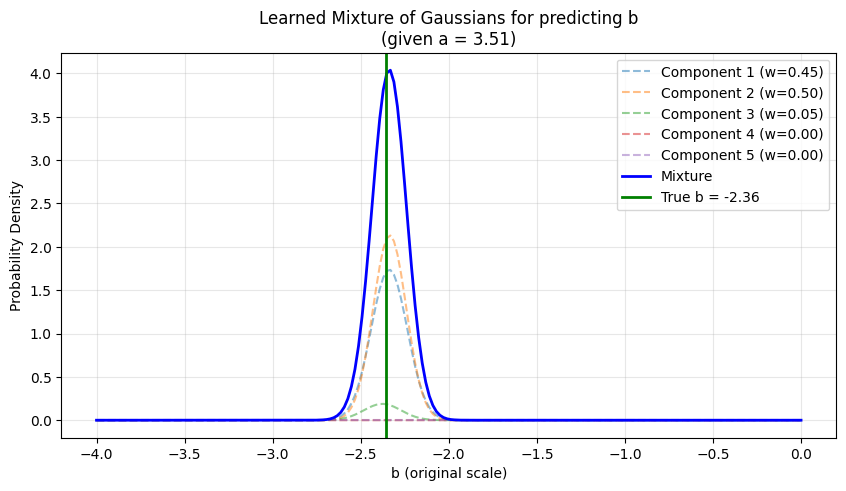

In [14]:
# Extract mixture parameters
w = weights[0, b_pos].numpy()
m = means[0, b_pos].numpy()
s = np.exp(0.5 * log_vars[0, b_pos].numpy())

# Inverse transform means to original scale for plotting
stats = scaler.get_scaler_stats("b")
m_orig = m * stats["std"] + stats["mean"]
s_orig = s * stats["std"]

x = np.linspace(-4, 0, 200)

# Plot mixture PDF
fig, ax = plt.subplots(figsize=(10, 5))

# Individual components
for i, (wi, mi, si) in enumerate(zip(w, m_orig, s_orig, strict=True)):
    pdf = wi * np.exp(-0.5 * ((x - mi) / si) ** 2) / (si * np.sqrt(2 * np.pi))
    ax.plot(x, pdf, "--", alpha=0.5, label=f"Component {i + 1} (w={wi:.2f})")

# Mixture PDF
mixture_pdf = np.zeros_like(x)
for wi, mi, si in zip(w, m_orig, s_orig, strict=True):
    mixture_pdf += wi * np.exp(-0.5 * ((x - mi) / si) ** 2) / (si * np.sqrt(2 * np.pi))
ax.plot(x, mixture_pdf, "b-", linewidth=2, label="Mixture")

# Mark true value
true_val = test_docs[0]["b"]
ax.axvline(true_val, color="green", linestyle="-", linewidth=2, label=f"True b = {true_val:.2f}")

ax.set_xlabel("b (original scale)")
ax.set_ylabel("Probability Density")
ax.set_title(f"Learned Mixture of Gaussians for predicting b\n(given a = {test_docs[0]['a']:.2f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Summary

This notebook demonstrated how to use `OrigamiPipeline` with continuous numeric values:

1. **Simple configuration**: Set `numeric_mode="scale"` to enable automatic preprocessing and continuous head

2. **One-line training**: `pipeline.fit(data)` handles preprocessing, tokenization, model creation, and training

3. **Automatic inverse transform**: `pipeline.generate()` and `pipeline.predict()` return values in the original scale

4. **Unified save/load**: `pipeline.save()` and `OrigamiPipeline.load()` preserve all state

**Key API methods:**
```python
# Create and configure
pipeline = OrigamiPipeline(PipelineConfig(numeric_mode="scale"))

# Train
pipeline.fit(train_data, eval_data=eval_data, epochs=20)

# Generate samples (auto inverse-transformed)
samples = pipeline.generate(num_samples=100)

# Predict missing field (auto inverse-transformed)
prediction = pipeline.predict({"a": 3.5, "b": None}, target_key="b")

# Save/load
pipeline.save("model.pt")
loaded = OrigamiPipeline.load("model.pt")
```

The continuous head with Mixture of Gaussians is particularly useful for:
- High-cardinality numeric fields that would require too many bins if discretized
- Preserving continuous relationships between fields
- Generating realistic numeric values from learned distributions